In [1]:
# ===========================
# Imports, reproducibility Setup, data loaders and viz
# ===========================
import os, random, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
from torch.utils.data import TensorDataset, DataLoader

# ---- Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = (torch.initial_seed() % 2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# ---- Device selection
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Using device: {device}")


Using device: cuda


# BloodMnist Data Download and basic stats

BloodMNIST: (11959, 28, 28, 3) (11959,) | (1712, 28, 28, 3) (1712,) | (3421, 28, 28, 3) (3421,)


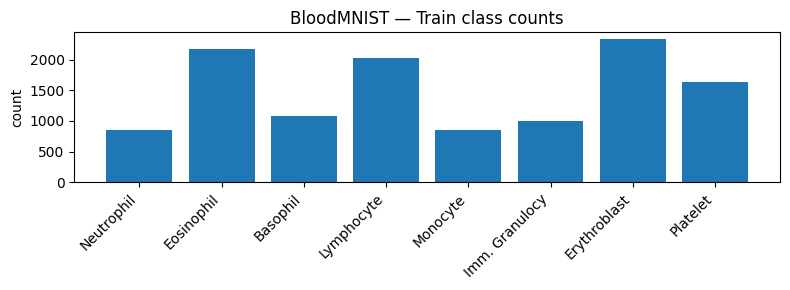

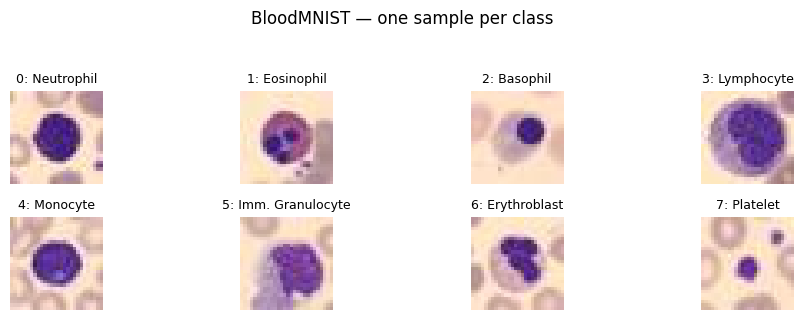

In [2]:

# ---- Download & load (official MedMNIST v2 NPZ)
os.makedirs("data", exist_ok=True)
BLOOD_URL  = "https://zenodo.org/records/5208230/files/bloodmnist.npz"
BLOOD_PATH = "data/bloodmnist.npz"
if not os.path.exists(BLOOD_PATH):
    print("Downloading BloodMNIST (~40MB)...")
    urllib.request.urlretrieve(BLOOD_URL, BLOOD_PATH)

d = np.load(BLOOD_PATH)
Xtr, ytr = d["train_images"], d["train_labels"].squeeze()
Xva, yva = d["val_images"],   d["val_labels"].squeeze()
Xte, yte = d["test_images"],  d["test_labels"].squeeze()
print("BloodMNIST:", Xtr.shape, ytr.shape, "|", Xva.shape, yva.shape, "|", Xte.shape, yte.shape)

# ---- Class names
BLOOD_CLASSES = [
    "Neutrophil","Eosinophil","Basophil","Lymphocyte",
    "Monocyte","Imm. Granulocyte","Erythroblast","Platelet"
]

# ---- Per-class counts (train)
train_counts = Counter(ytr.tolist())
plt.figure(figsize=(8,3))
plt.bar(range(8), [train_counts[i] for i in range(8)])
plt.xticks(range(8), [c[:14] for c in BLOOD_CLASSES], rotation=45, ha="right")
plt.ylabel("count")
plt.title("BloodMNIST — Train class counts")
plt.tight_layout(); plt.show()

# ---- One example per class (from train)
plt.figure(figsize=(10,3))
for c in range(8):
    idx = np.where(ytr == c)[0][0]
    plt.subplot(2,4,c+1)
    plt.imshow(Xtr[idx])               # RGB
    plt.axis("off")
    plt.title(f"{c}: {BLOOD_CLASSES[c]}", fontsize=9)
plt.suptitle("BloodMNIST — one sample per class", y=1.05)
plt.tight_layout(); plt.show()



### Pytorch Data Loader for the  Blood Mnist DataSet

In [3]:
# ---- Tensor conversion (CHW, float in [0,1])
def to_tensor(X, y):
    X = torch.tensor(X, dtype=torch.float32).permute(0,3,1,2) / 255.0  # [N,3,28,28]
    y = torch.tensor(y, dtype=torch.long)
    return X, y

Xt, yt = to_tensor(Xtr, ytr)
Xv, yv = to_tensor(Xva, yva)
Xs, ys = to_tensor(Xte, yte)

# DataLoaders
train_loader = DataLoader(
    TensorDataset(Xt, yt), batch_size=32, shuffle=True,
    num_workers=2, worker_init_fn=seed_worker, pin_memory=(device.type=="cuda")
)
val_loader = DataLoader(
    TensorDataset(Xv, yv), batch_size=32, shuffle=False,
    num_workers=2, worker_init_fn=seed_worker, pin_memory=(device.type=="cuda")
)
test_loader = DataLoader(
    TensorDataset(Xs, ys), batch_size=32, shuffle=False,
    num_workers=2, worker_init_fn=seed_worker, pin_memory=(device.type=="cuda")
)

# ---- Quick sanity: one batch
xb, yb = next(iter(train_loader))
print("BloodMNIST batch:", tuple(xb.shape), tuple(yb.shape), xb.dtype, xb.min().item(), xb.max().item())


BloodMNIST batch: (32, 3, 28, 28) (32,) torch.float32 0.01568627543747425 1.0


In [4]:
## Start Building Models, Defining Loss, Optimizers, Train Loop, Test Loop, Evaluation Metrics, Hyperparameters.

In [5]:
!pip install -q wandb scikit-learn
import wandb
wandb.login()  # API key

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: alex-lee-saeyun (alex-lee-saeyun-texas-christian-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

This cell defines the hyperparameter configuration for the MLP model including the number of hidden layers, activation function, dropout, batch normalization, learning rate, and weight decay.

In [6]:
# =========================
# HW3 - BloodMNIST MLP: Models, Training, Evaluation, WandB
# (Continue from the provided boilerplate)

import torch.nn as nn
import torch.nn.functional as FNt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import itertools

# Optional: Weights & Biases for experiment tracking
USE_WANDB = True  # set to False if don't want to log

try:
    import wandb
    if USE_WANDB:
        # This is to make sure this was already ran: !pip install -q wandb scikit-learn
        pass
except ImportError:
    print("wandb is not installed; set USE_WANDB = False or install wandb.")
    USE_WANDB = False

# ---- Basic training configuration
mlp_config = {
    "input_dim": 28 * 28 * 3,
    "num_classes": len(BLOOD_CLASSES),
    "hidden_dims": [512, 256, 128], # This creates a 3-layer MLP (512 → 256 → 128), satisfying the requirement.
    "dropout": 0.5,
    "activation": "relu",      # Can change to: "relu", "leaky_relu", "tanh"
    "use_batchnorm": True,
    "num_epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 32,
}

The activation helper translates activation names into PyTorch layers and the BloodMLP class defines the full architecture. The model uses three hidden layers with batch normalization and dropout which satisfies the assignment requirement of building a two to four layer MLP that explores different design choices. Flattening the input and passing it through these layers for eight class classification.

In [7]:
# ------------------------------------------------------------
# Keeps all features but removes unnecessary complexity
# ------------------------------------------------------------

import torch.nn as nn

def make_activation(name):
    name = name.lower()
    if name == "relu": return nn.ReLU()
    if name == "leaky_relu": return nn.LeakyReLU(0.1)
    if name == "tanh": return nn.Tanh()
    raise ValueError("Unsupported activation:", name)

class BloodMLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        layers = []
        dims = [cfg["input_dim"]] + cfg["hidden_dims"]

        for in_dim, out_dim in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(in_dim, out_dim))

            if cfg["use_batchnorm"]:
                layers.append(nn.BatchNorm1d(out_dim))

            layers.append(make_activation(cfg["activation"]))
            layers.append(nn.Dropout(cfg["dropout"]))

        self.layers = nn.Sequential(*layers)
        self.output = nn.Linear(dims[-1], cfg["num_classes"])

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = self.layers(x)
        return self.output(x)

This cell defines two functions that perform one full pass over the training set and one full pass over the validation or test set. They compute both accuracy and loss and return predictions when needed. These functions allow consistent comparison between optimizers which is required by the assignment and provide the metrics needed for W&B logging and curve plotting.

In [8]:
# ------------------------------------------------------------
# Simple training and evaluation functions
# ------------------------------------------------------------

def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total, correct, loss_sum = 0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        scores = model(x)
        loss = loss_fn(scores, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * y.size(0)
        correct += (scores.argmax(1) == y).sum().item()
        total += y.size(0)

    return loss_sum / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, loss_fn):
    model.eval()
    total, correct, loss_sum = 0, 0, 0
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        scores = model(x)
        loss = loss_fn(scores, y)

        loss_sum += loss.item() * y.size(0)
        correct += (scores.argmax(1) == y).sum().item()
        total += y.size(0)

        all_preds.append(scores.argmax(1).cpu())
        all_labels.append(y.cpu())

    return (
        loss_sum / total,
        correct / total,
        torch.cat(all_preds),
        torch.cat(all_labels),
    )

This is the main training cell where the MLP is trained using either SGD or Adam. It handles optimizer selection, epoch loops, validation checks, W&B logging, model checkpointing, and final test scoring. This cell directly fulfills the assignment requirement to train the model with at least two optimizers and compare their performance. It also satisfies the W&B requirement by logging accuracy and loss every epoch.

In [9]:
def run_experiment(opt_name, cfg):

    model = BloodMLP(cfg).to(device)
    loss_fn = nn.CrossEntropyLoss()

    if opt_name == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=cfg["lr"],
            momentum=0.9,
            weight_decay=cfg["weight_decay"]
        )
    else:
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=cfg["lr"],
            weight_decay=cfg["weight_decay"]
        )

    # ---- W&B
    if USE_WANDB:
        wandb.init(
            project="bloodMinst",
            name=f"blood_mlp_{opt_name}",        # e.g. blood_mlp_sgd
            config={
                "dataset": "BloodMNIST",
                "model": "MLP",
                "optimizer": opt_name,
                **cfg
            }
        )

    history = {"train_acc": [], "val_acc": []}
    best_state = None
    best_val = 0

    for epoch in range(cfg["num_epochs"]):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc, _, _ = eval_epoch(model, val_loader, loss_fn)

        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if USE_WANDB:
            # log both accuracy and loss, along with epoch index
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": tr_loss,
                "val_loss": va_loss,
                "train_acc": tr_acc,
                "val_acc": va_acc,
            })

        print(f"{opt_name.upper()} Epoch {epoch+1}: "
              f"Train Acc={tr_acc:.3f}  Val Acc={va_acc:.3f}")

        if va_acc > best_val:
            best_val = va_acc
            best_state = model.state_dict()

    model.load_state_dict(best_state)

    test_loss, test_acc, preds, labels = eval_epoch(model, test_loader, loss_fn)

    if USE_WANDB:
        wandb.log({
            "test_loss": test_loss,
            "test_acc": test_acc
        })
        wandb.finish()

    return model, history, preds, labels

This part uses the experiment runner to train two models, one with SGD and one with Adam. Their histories and predictions are stored for later comparison.

In [10]:
results = {}

for opt in ["sgd", "adam"]:
    print("\n========== Running", opt.upper(), "==========")
    model, hist, preds, labels = run_experiment(opt, mlp_config)
    results[opt] = {"history": hist, "preds": preds, "labels": labels}


========== Running SGD ==========


SGD Epoch 1: Train Acc=0.503  Val Acc=0.691
SGD Epoch 2: Train Acc=0.663  Val Acc=0.774
SGD Epoch 3: Train Acc=0.712  Val Acc=0.790
SGD Epoch 4: Train Acc=0.729  Val Acc=0.803
SGD Epoch 5: Train Acc=0.752  Val Acc=0.819
SGD Epoch 6: Train Acc=0.759  Val Acc=0.827
SGD Epoch 7: Train Acc=0.770  Val Acc=0.815
SGD Epoch 8: Train Acc=0.773  Val Acc=0.817
SGD Epoch 9: Train Acc=0.786  Val Acc=0.828
SGD Epoch 10: Train Acc=0.791  Val Acc=0.836
SGD Epoch 11: Train Acc=0.793  Val Acc=0.811
SGD Epoch 12: Train Acc=0.803  Val Acc=0.832
SGD Epoch 13: Train Acc=0.804  Val Acc=0.838
SGD Epoch 14: Train Acc=0.811  Val Acc=0.848
SGD Epoch 15: Train Acc=0.809  Val Acc=0.846
SGD Epoch 16: Train Acc=0.820  Val Acc=0.876
SGD Epoch 17: Train Acc=0.823  Val Acc=0.868
SGD Epoch 18: Train Acc=0.824  Val Acc=0.852
SGD Epoch 19: Train Acc=0.830  Val Acc=0.848
SGD Epoch 20: Train Acc=0.830  Val Acc=0.863
SGD Epoch 21: Train Acc=0.837  Val Acc=0.856
SGD Epoch 22: Train Acc=0.837  Val Acc=0.855
SGD Epoch 23: Train

epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁
test_loss,▁
train_acc,▁▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
train_loss,█▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▅▆▅▆▆▆▅▆▇▇█▇▇▇▇▇▇▇█▇▇▇█▇▇▇▇██▇▇██████
val_loss,█▆▅▄▄▃▃▃▄▃▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▂▂▂▂▁▂▁▁▁▁▁▁▁▁
epoch,50
test_acc,0.87284
test_loss,0.35757
train_acc,0.88912



========== Running ADAM ==========


ADAM Epoch 1: Train Acc=0.651  Val Acc=0.615
ADAM Epoch 2: Train Acc=0.740  Val Acc=0.703
ADAM Epoch 3: Train Acc=0.777  Val Acc=0.772
ADAM Epoch 4: Train Acc=0.785  Val Acc=0.699
ADAM Epoch 5: Train Acc=0.796  Val Acc=0.785
ADAM Epoch 6: Train Acc=0.807  Val Acc=0.801
ADAM Epoch 7: Train Acc=0.813  Val Acc=0.808
ADAM Epoch 8: Train Acc=0.820  Val Acc=0.846
ADAM Epoch 9: Train Acc=0.827  Val Acc=0.827
ADAM Epoch 10: Train Acc=0.828  Val Acc=0.721
ADAM Epoch 11: Train Acc=0.828  Val Acc=0.794
ADAM Epoch 12: Train Acc=0.839  Val Acc=0.845
ADAM Epoch 13: Train Acc=0.833  Val Acc=0.832
ADAM Epoch 14: Train Acc=0.836  Val Acc=0.793
ADAM Epoch 15: Train Acc=0.836  Val Acc=0.811
ADAM Epoch 16: Train Acc=0.846  Val Acc=0.790
ADAM Epoch 17: Train Acc=0.850  Val Acc=0.770
ADAM Epoch 18: Train Acc=0.852  Val Acc=0.837
ADAM Epoch 19: Train Acc=0.848  Val Acc=0.830
ADAM Epoch 20: Train Acc=0.857  Val Acc=0.854
ADAM Epoch 21: Train Acc=0.856  Val Acc=0.845
ADAM Epoch 22: Train Acc=0.856  Val Acc=0.7

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
test_acc,▁
test_loss,▁
train_acc,▁▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████████
train_loss,█▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▃▆▆▇▇▄▆▇▆▆▆▅▇▇▆▇▇▇▇▇▇▇▆▇▇▅▆█▅▆▇▇██▇▇▇
val_loss,█▆▄▇▃▃▂▂▅▃▂▃▃▄▄▂▂▂▃▂▃▂▂▂▂▃▃▂▅▃▁▄▄▂▂▁▁▂▁▂
epoch,50
test_acc,0.82549
test_loss,0.48767
train_acc,0.88369


This cell plots the training and validation accuracy curves for both optimizers so that their learning behavior can be compared visually. It also makes it easier to interpret which optimizer performs better.

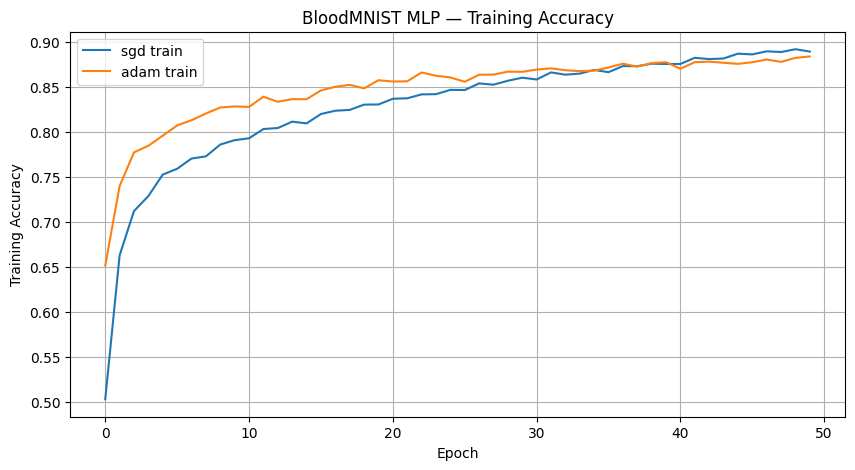

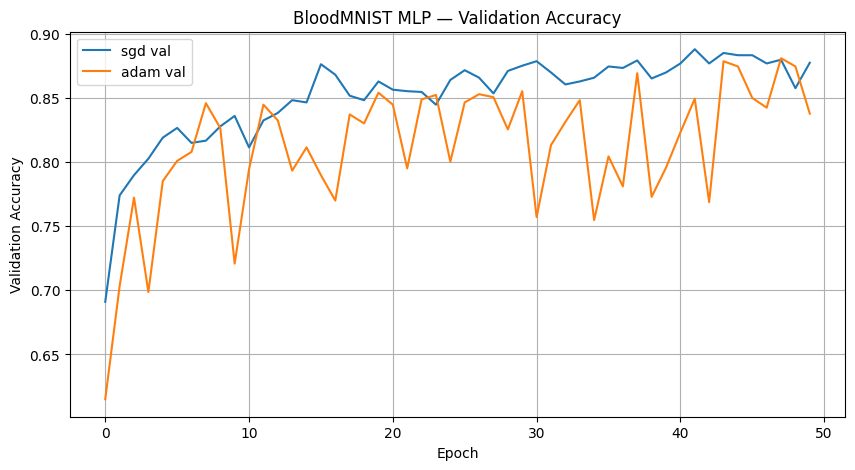

In [11]:
def plot_curves_separate(results):
    # --------------------------
    # Training Accuracy Plot
    # --------------------------
    plt.figure(figsize=(10,5))
    for opt in results:
        plt.plot(results[opt]["history"]["train_acc"], label=f"{opt} train")
    plt.xlabel("Epoch")
    plt.ylabel("Training Accuracy")
    plt.title("BloodMNIST MLP — Training Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    # --------------------------
    # Validation Accuracy Plot
    # --------------------------
    plt.figure(figsize=(10,5))
    for opt in results:
        plt.plot(results[opt]["history"]["val_acc"], label=f"{opt} val")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("BloodMNIST MLP — Validation Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

# Call the plotting function
plot_curves_separate(results)

This cell identifies which optimizer reached the highest validation accuracy and produces a confusion matrix for each model. This visualization shows where each optimizer struggles and provides deeper insight into the classification performance.

Best optimizer: SGD

Confusion Matrix for SGD


<Figure size 700x600 with 0 Axes>

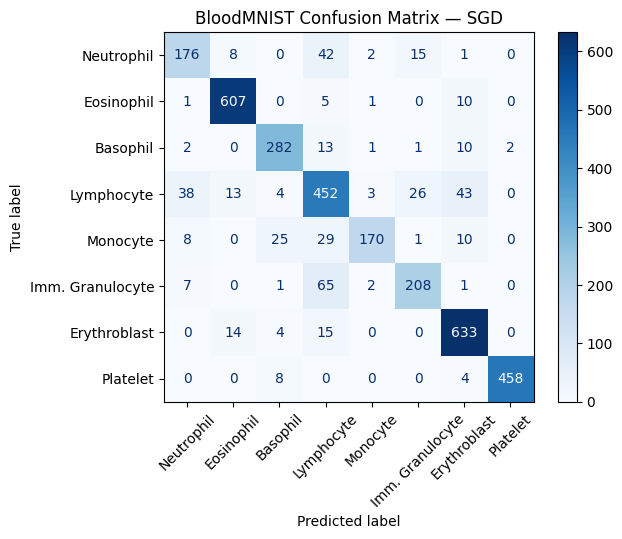


Confusion Matrix for ADAM


<Figure size 700x600 with 0 Axes>

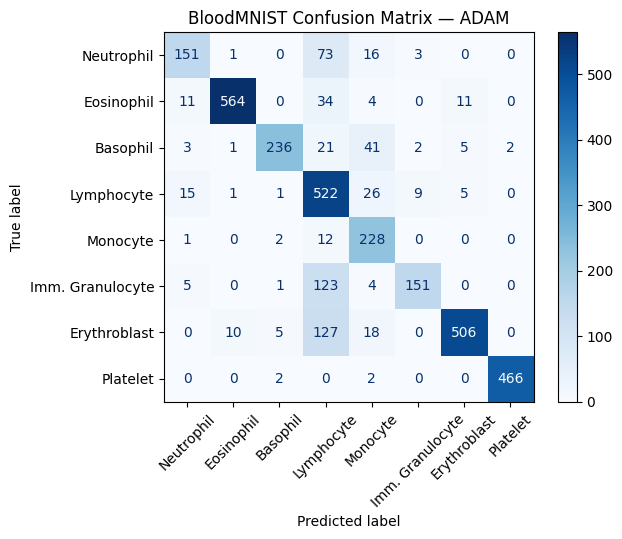

In [12]:
# -------------------------------------------------------------
# Identify best optimizer
# -------------------------------------------------------------
best_opt = max(results, key=lambda o: max(results[o]["history"]["val_acc"]))
print("Best optimizer:", best_opt.upper())

# -------------------------------------------------------------
# Plot confusion matrix for each optimizer
# -------------------------------------------------------------
for opt in results:
    print(f"\nConfusion Matrix for {opt.upper()}")

    y_true = results[opt]["labels"]
    y_pred = results[opt]["preds"]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=BLOOD_CLASSES)

    plt.figure(figsize=(7,6))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"BloodMNIST Confusion Matrix — {opt.upper()}")
    plt.show()

The final cell prints the best validation accuracy for SGD and Adam and provides a short summary stating which optimizer performed better overall.

In [13]:
# -------------------------------------------------------------
# Compare maximum validation accuracy for SGD and Adam
# -------------------------------------------------------------

sgd_best = max(results["sgd"]["history"]["val_acc"])
adam_best = max(results["adam"]["history"]["val_acc"])

print(f"Best SGD validation accuracy:  {sgd_best:.4f}")
print(f"Best Adam validation accuracy: {adam_best:.4f}")

if adam_best > sgd_best:
    print("\nAdam performed better overall.")
elif sgd_best > adam_best:
    print("\nSGD performed better overall.")
else:
    print("\nBoth optimizers performed equally well.")

Best SGD validation accuracy:  0.8879
Best Adam validation accuracy: 0.8808

SGD performed better overall.
